In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from typing import Optional
from states_extract import StateExtractor, StatesDataset
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.datasets.phonemes import get_phoneme_to_id
from ast import literal_eval
from sklearn.decomposition import PCA

In [4]:
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "../reproduce/weights/1024_75.pth"
dataset_load = "train" # or "test"

In [7]:
seed_everything(42)
device = set_device()
#  Setup
model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)
model.eval()
phoneme_to_id = get_phoneme_to_id()
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}
converters = {"Word": str, "Phonemes": literal_eval, "No_Stress": literal_eval}

extractor = StateExtractor(model, phoneme_to_id, device)
# Load phoneme categories
phoneme_data = pd.read_csv("datasets/phonemes.csv")
vowels = phoneme_data["Phoneme"][phoneme_data["Type"] == "V"].tolist()
consonants = phoneme_data["Phoneme"][phoneme_data["Type"] == "C"].tolist()
if dataset_load == "train":
    dataset = StatesDataset.load("states_ds/train_states_with_hc") # train dataset with 30k real words
elif dataset_load == "test":
    dataset = StatesDataset.load("states_ds/wfe_states") # 1200 words real and pseudo words


Using MPS device


# intervention test

In [193]:
from scipy import stats
from sklearn.decomposition import PCA

def get_median_angle(ph_embs_2d, mask):
    ph_angles = np.arctan2(ph_embs_2d[:,1], ph_embs_2d[:,0])
    ph_angle_mean = stats.circmean(ph_angles)
    return ph_angle_mean

def get_angle_inverse(pca, angle):
    point_2d = np.array([[np.cos(angle), np.sin(angle)]])
    inverse = pca.inverse_transform(point_2d)
    return inverse / np.linalg.norm(inverse)


def get_pca(mask, state='state', d=2):
    embs = dataset.get_embeddings(f"delta_{state}", mask)
    pca = PCA(n_components=d)
    embs_2d = pca.fit_transform(embs)
    return embs_2d, pca

In [194]:
max_pos_mask = dataset.metadata["position"] <= 8
embs_2d, pca = get_pca(max_pos_mask, state='state', d=2)


/var/folders/ll/yd1jcjfx6bddqdh1n23q0j1m0000gn/T/ipykernel_47001/2093661409.py:16: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



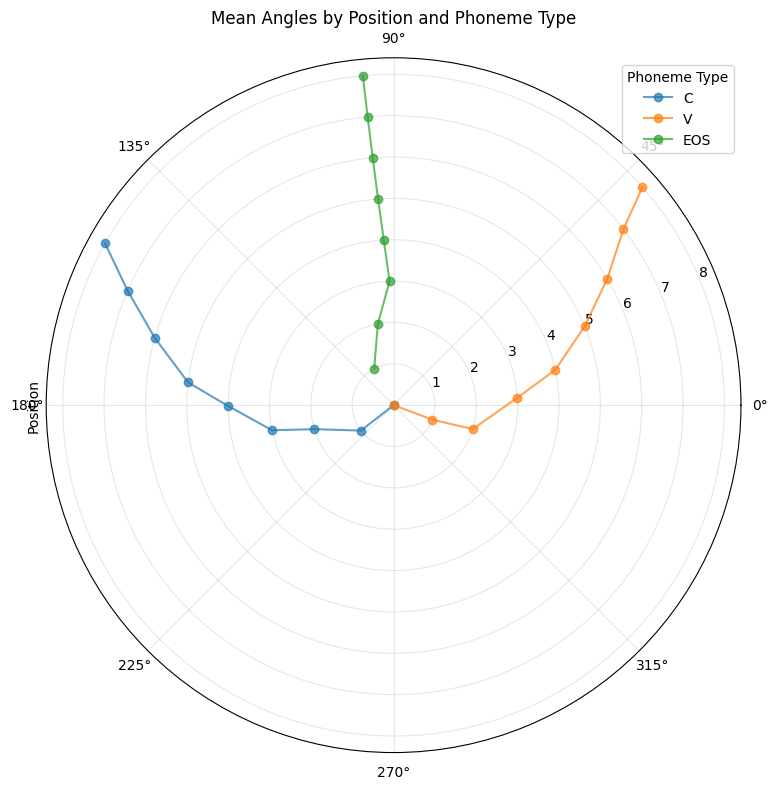

In [195]:
from scipy import stats
# Calculate mean angle for each phoneme type at each position
mean_angles_by_pos = {}
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

for ph_type in dataset.metadata["phoneme_type"].unique():
    mean_angles_by_pos[ph_type] = []
    
    for pos in range(0, 9):
        mask = dataset.get_mask(phoneme_type=ph_type, position=pos)
        
        type_embs_2d = embs_2d[mask[max_pos_mask]]
        angles = np.arctan2(type_embs_2d[:,1], type_embs_2d[:,0])
        
        # Compute circular mean angle for this position
        mean_angle = stats.circmean(angles)
        mean_angles_by_pos[ph_type].append((pos, mean_angle))
    
    # Plot line for this phoneme type
    positions, angles = zip(*mean_angles_by_pos[ph_type])
    ax.plot(angles, positions, marker='o', label=ph_type, alpha=0.7)

ax.set_title("Mean Angles by Position and Phoneme Type")
ax.set_ylabel("Position")
ax.legend(title="Phoneme Type")
ax.grid(True, alpha=0.3)
plt.tight_layout()



In [182]:
# norms of pos in scale_pos
scale_pos = {}
for ph_type in dataset.metadata["phoneme_type"].unique():
    scale_pos[ph_type] = []
    for pos in range(0, 9):
        mask = (dataset.metadata["phoneme_type"] == ph_type) & (dataset.metadata["position"] == pos)
        scale_pos[ph_type].append(np.mean(norms(dataset.delta_state[mask])))
scale_pos

# avg of delta_state for types and positions, devided by norm
mean_directions = {}
for ph_type in dataset.metadata["phoneme_type"].unique():
    mean_directions[ph_type] = []
    for pos in range(0, 9):
        mask = (dataset.metadata["phoneme_type"] == ph_type) & (dataset.metadata["position"] == pos)
        mean_delta = np.mean(dataset.delta_state[mask], axis=0)
        # norm = np.linalg.norm(mean_delta)
        mean_directions[ph_type].append(mean_delta)

In [198]:
def get_encoder_hidden(input_ids):
        """Get final hidden state from encoder LSTM."""
        with torch.no_grad():
            (h, c) = model.encoder(input_ids)
            return h[-1] , c[-1] 
def state_to_hc(state):
    # split on axis 1
    h = state.reshape(-1, 256)[:, :128]
    c = state.reshape(-1, 256)[:, 128:]
    
    h = h.float().to(device)
    c = c.float().to(device)
    h = h.unsqueeze(0)  # add batch dimension
    c = c.unsqueeze(0)  # add batch dimension
    return h, c
def h_c_to_state(h, c):
    h = torch.as_tensor(h)
    c = torch.as_tensor(c)
    return torch.cat((h, c), dim=-1)
        
def decode_to_phones(hidden_states, phon_seq, teacher_forcing=False):
    
    sos_token_id = phoneme_to_id["<SOS>"]
    inp = torch.full((1, 1), sos_token_id, dtype=torch.long).to(device)
    outputs = []

    for t in range(len(phon_seq)): 
        embedded = model.decoder.embedding(inp)
        embedded = model.decoder.dropout(embedded)
        out, hidden_states = model.decoder.recurrent(embedded, hidden_states)
        logits = out @ model.decoder.embedding.weight.T
        outputs.append(logits)
        
        if teacher_forcing:
            # Convert phoneme to token ID, then to tensor
            token_id = phoneme_to_id.get(phon_seq[t])
            inp = torch.full((1, 1), token_id, dtype=torch.long).to(device)
        else:
            inp = logits.argmax(dim=-1)

    predicted_phonemes = [id_to_phoneme[logit.argmax().item()] for logit in outputs]
    # print(f"target pos {pos}: {predicted_phonemes}")
    return predicted_phonemes

In [183]:
def intervene_on_pos(word, pos, old_state, phon_seq):
    phone_to_change = phon_seq[pos]
    
    phone_to_change_state = dataset.get_embeddings('delta_state')[dataset.get_mask(seq_condition=word, position=pos)]



    new_phone_type = "V" if phone_to_change in consonants else "C"

    # new_phone_prototype = get_angle_inverse(pca, mean_angles_by_pos[new_phone_type][pos][1]) * scale_pos[new_phone_type][pos]
    new_phone_prototype = mean_directions[new_phone_type][pos]

    new_state = old_state.cpu() - phone_to_change_state + new_phone_prototype 
    new_hidden_states = state_to_hc(new_state)
    pred = decode_to_phones(new_hidden_states, phon_seq, teacher_forcing=False)
    return pred
    # print(f"Changing position {pos+1} from '{phone_to_change}' to  {new_phone_type}")
    # print(f"Result: {pred}")

In [144]:
# test with start changing first C to V
word = "book" 
phon_seq = dataset.metadata[dataset.get_mask(seq_condition=word)]["phoneme"].values
phon_seq_id = [phoneme_to_id[phon] for phon in phon_seq]
phon_seq_tensor = torch.tensor([phon_seq_id], dtype=torch.long).to(device)  
old_h, old_c = get_encoder_hidden(phon_seq_tensor)
old_state = h_c_to_state(old_h, old_c)
phon_seq

<StringArray>
['B', 'UH', 'K', '<EOS>']
Length: 4, dtype: str

In [146]:
for pos in range(len(phon_seq)-1):
    intervene_on_pos(word, pos=pos, old_state=old_state, phon_seq=phon_seq)

Changing position 1 from 'B' to  V
Result: ['B', 'UH', 'K', 'AH']
Changing position 2 from 'UH' to  C
Result: ['B', 'EY', 'K', '<EOS>']
Changing position 3 from 'K' to  V
Result: ['B', 'UH', 'ER', '<EOS>']


real mean direction seem to work better but they are not perfect yet
but it can change the pos and type successfully however the following phonemes get effected too!
can this be related to the decoder?

in many cases the phoneme in target position gets removed and sequence shifts and another phoneme is 
added at the end, this might be becaus i am removing the actual delta state but the added phoneme method is not precise

many IH NG added at the end - which is ing!

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [159]:
df_test = pd.read_csv("datasets/wfe_clean.csv")
df_test= df_test[df_test["Lexicality"]=='real']

In [184]:
results = []
def test_intervention_on_word(word):
    phon_seq = dataset.metadata[dataset.get_mask(seq_condition=word)]["phoneme"].values
    phon_seq_id = [phoneme_to_id[phon] for phon in phon_seq]
    phon_seq_tensor = torch.tensor([phon_seq_id], dtype=torch.long).to(device)  
    old_h, old_c = get_encoder_hidden(phon_seq_tensor)
    old_state = h_c_to_state(old_h, old_c)
    for pos in range(len(phon_seq)-1):
        pred = intervene_on_pos(word, pos=pos, old_state=old_state, phon_seq=phon_seq)
        results.append((word,pos, phon_seq, pred))



In [185]:
from tqdm import tqdm

for word in tqdm(df_test["Word"].unique()):
    test_intervention_on_word(word)

100%|██████████| 798/798 [01:35<00:00,  8.39it/s]


In [188]:
# convert results to dataframe
results_df = pd.DataFrame(results, columns=["Word", "Pos", "phone_seq", "Pred"])
results_df.head()

,Word,Pos,phone_seq,Pred
0,attending,0,"[AH, T, EH, N, D, IH, NG, <EOS>]","[T, EH, N, D, IH, NG, W, AH]"
1,attending,1,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, N, EH, D, IH, NG, AH, <EOS>]"
2,attending,2,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, D, N, IH, NG, W, AO]"
3,attending,3,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, EH, D, IH, NG, AH, <EOS>]"
4,attending,4,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, EH, N, IH, NG, AH, <EOS>]"


In [189]:
# add columns	Condition	Lexicality	Size	Morphology	Frequency	Length from df_test by matching word
results_df = results_df.merge(df_test[["Word", "Condition", "Lexicality", "Size", "Morphology", "Frequency", "Length"]], on="Word", how="left")


In [190]:
# add columns gold_type_seq and pred_type_seq by mapping phonemes to types
def map_phonemes_to_types(phon_seq, pos):
    # map to type but switch the type at pos
    type_seq = []
    for i, phon in enumerate(phon_seq):
        if i == pos:
            type_seq.append("V" if phon in consonants else "C")
        else:
            type_seq.append("C" if phon in consonants else ("V" if phon in vowels else phon))

    return type_seq
results_df["gold_type_seq"] = results_df.apply(lambda row: map_phonemes_to_types(row["phone_seq"], row["Pos"]), axis=1)
results_df["pred_type_seq"] = results_df.apply(lambda row: map_phonemes_to_types(row["Pred"], -1), axis=1)


In [194]:
# calculatr error by comparing gold_type_seq and pred_type_seq, count how many positions are different
def calculate_error(gold_type_seq, pred_type_seq):
    errors = sum(1 for g, p in zip(gold_type_seq, pred_type_seq) if g != p)
    return errors

results_df["error"] = results_df.apply(lambda row: calculate_error(row["gold_type_seq"], row["pred_type_seq"]), axis=1)
results_df.head()

,Word,Pos,phone_seq,Pred,Condition,Lexicality,Size,Morphology,Frequency,Length,gold_type_seq,pred_type_seq,error
0,attending,0,"[AH, T, EH, N, D, IH, NG, <EOS>]","[T, EH, N, D, IH, NG, W, AH]",RLCH,real,long,complex,0.00002,7,"[C, C, V, C, C, V, C, <EOS>]","[C, V, C, C, V, C, C, V]",5
1,attending,1,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, N, EH, D, IH, NG, AH, <EOS>]",RLCH,real,long,complex,0.00002,7,"[V, V, V, C, C, V, C, <EOS>]","[V, C, V, C, V, C, V, <EOS>]",4
2,attending,2,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, D, N, IH, NG, W, AO]",RLCH,real,long,complex,0.00002,7,"[V, C, C, C, C, V, C, <EOS>]","[V, C, C, C, V, C, C, V]",3
3,attending,3,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, EH, D, IH, NG, AH, <EOS>]",RLCH,real,long,complex,0.00002,7,"[V, C, V, V, C, V, C, <EOS>]","[V, C, V, C, V, C, V, <EOS>]",4
4,attending,4,"[AH, T, EH, N, D, IH, NG, <EOS>]","[AH, T, EH, N, IH, NG, AH, <EOS>]",RLCH,real,long,complex,0.00002,7,"[V, C, V, C, V, V, C, <EOS>]","[V, C, V, C, V, C, V, <EOS>]",2


In [221]:
results_df[(results_df["error"] == 0)& (results_df["Pos"] ==3)][['Word','Length','Pos','phone_seq','Pred']]#[5:15]

,Word,Length,Pos,phone_seq,Pred
80,perfectly,8,3,"[P, ER, F, AH, K, T, L, IY, <EOS>]","[P, ER, F, K, T, S, L, IY, <EOS>]"
262,racism,7,3,"[R, EY, S, IH, Z, AH, M, <EOS>]","[R, EY, S, Z, M, AH, S, <EOS>]"
539,supports,7,3,"[S, AH, P, AO, R, T, S, <EOS>]","[S, AH, P, T, R, S, P, <EOS>]"
1179,bulldozer,7,3,"[B, UH, L, D, OW, Z, ER, <EOS>]","[B, UH, L, OW, ER, Z, IY, <EOS>]"
1287,unisex,8,3,"[Y, UW, N, IH, S, EH, K, S, <EOS>]","[Y, UW, N, S, K, EH, R, S, <EOS>]"
...,...,...,...,...,...
4618,aloof,4,3,"[AH, L, UW, F, <EOS>]","[AH, L, UW, AH, <EOS>]"
4639,bimbo,5,3,"[B, IH, M, B, OW, <EOS>]","[B, IH, M, OW, IH, <EOS>]"
4658,barley,5,3,"[B, AA, R, L, IY, <EOS>]","[B, AA, R, IY, AH, <EOS>]"
4691,nectar,5,3,"[N, EH, K, T, ER, <EOS>]","[N, EH, K, ER, AH, <EOS>]"


In [217]:
# error 0 percentage
results_df[results_df["error"] == 0].shape[0] / len(results_df)

0.12478920741989882

In [ ]:
3188

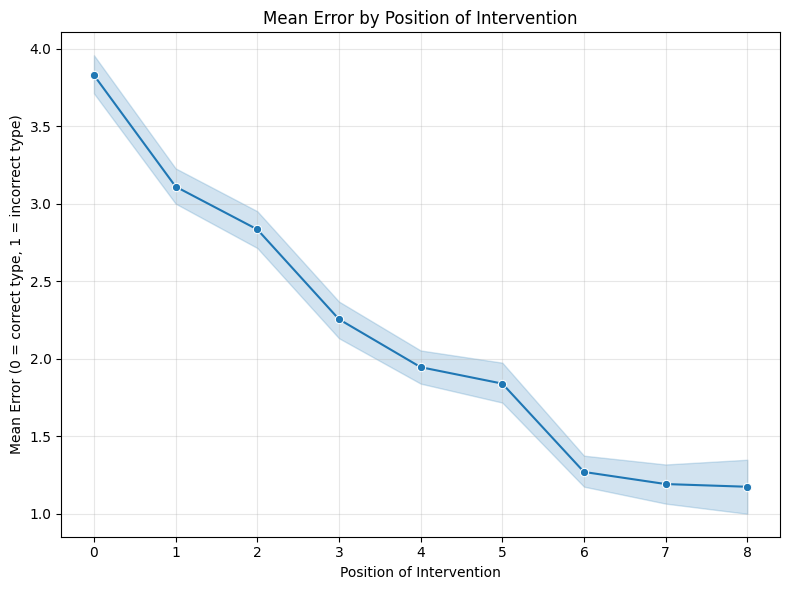

In [206]:
# plot error mean grouped by pos
plt.figure(figsize=(8, 6))
sns.lineplot(x="Pos", y="error", data=results_df, marker='o')
plt.title("Mean Error by Position of Intervention")
plt.xlabel("Position of Intervention")
plt.ylabel("Mean Error (0 = correct type, 1 = incorrect type)")
plt.grid(True, alpha=0.3)
plt.tight_layout()


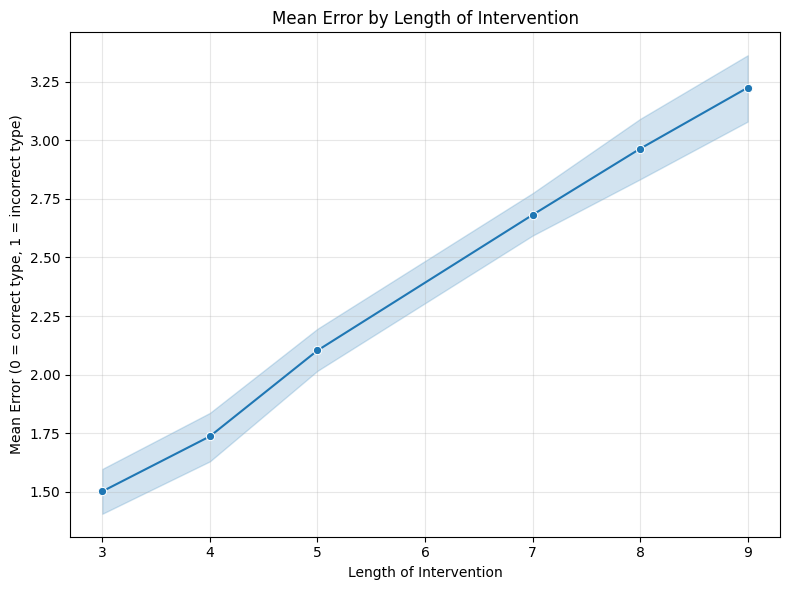

In [207]:
plt.figure(figsize=(8, 6))
sns.lineplot(x="Length", y="error", data=results_df, marker='o')
plt.title("Mean Error by Length of Intervention")
plt.xlabel("Length of Intervention")
plt.ylabel("Mean Error (0 = correct type, 1 = incorrect type)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [202]:
results_df.to_csv("results/state_intervention_results_mean_directions.csv", index=False)